<a href="https://colab.research.google.com/github/zorGizem/Erken-Evre-Alzhemir-Tespiti/blob/main/notebooks/kod/DenseNet_PerPlane_Ensemble_v2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DenseNet121 Per-Plane Ensemble — Train/Val + Izole Test

**Akis:**

```
            +--- Sagital (5 fold model) ---+
Egitim ---> +--- Aksiyal (5 fold model) ---+--> 15 model kaydedilir
(train/val) +--- Koronal (5 fold model) ---+
                                              |
                                              v
Izole TEST seti --> 15 model olasiligi (agirlikli ortalama) --> Final karar
```

**Bu defterin kurallari:**

1. **Test seti tamamen izole.** Test seti EL ILE, ayri 2 klasorden gelir
   (`Slice_CN_test`, `Slice_EMCI_test`). Egitim, validation, hiperparametre
   secimi veya model secimine HIC dahil edilmez. Sadece en son hucrede,
   birlestirilmis ensemble uzerinden BIR KEZ degerlendirilir.

2. **Egitim sadece train/validation uzerinden.** Her fold hastalar bazinda
   %85 train / %15 val olacak sekilde bolunur. Model secimi (EarlyStopping)
   yalniz **val_loss** uzerinden yapilir.

3. **5-Fold + Ensemble.** Her duzlem icin 5 fold model egitilir ve kaydedilir
   (3 duzlem x 5 fold = 15 model). Canli tahminde bu 15 model olasilik
   ortalamasi (soft voting) ile birlesir.

4. **Agirlikli ensemble.** Son hucrede `DUZLEM_AGIRLIK` sozlugu ile her duzleme
   farkli agirlik verilebilir. Su an hepsi esit (1.0 / 1.0 / 1.0).

5. **Nihai test.** En son hucrede izole test seti, birlesik ensemble uzerinden
   tek seferde test edilir; accuracy / precision / recall / F1 ve confusion
   matrix raporlanir.

**Ayni kalan her sey:** ImageNet normalize, class weights ACIK, label smoothing
0.1, weights_only=True, AdamW + Cosine scheduler, kismi-freeze DenseNet121.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import nibabel as nib
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

print(f"PyTorch: {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Cihaz  : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"Seed   : {SEED}")

PyTorch: 2.11.0+cu128
Cihaz  : cuda
GPU    : NVIDIA A100-SXM4-40GB
Seed   : 42


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import shutil, os

drive_path = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Slice_v2/'
zip_cn   = drive_path + 'Slice_CN.zip'
zip_emci = drive_path + 'Slice_EMCI.zip'

local_dir = '/content/dataset'
os.makedirs(local_dir, exist_ok=True)

if not os.path.exists(os.path.join(local_dir, 'Slice_CN')):
    print("Slice_CN aciliyor...")
    shutil.unpack_archive(zip_cn, local_dir)
    print("  Tamamlandi.")
else:
    print("Slice_CN zaten var.")

if not os.path.exists(os.path.join(local_dir, 'Slice_EMCI')):
    print("Slice_EMCI aciliyor...")
    shutil.unpack_archive(zip_emci, local_dir)
    print("  Tamamlandi.")
else:
    print("Slice_EMCI zaten var.")

print("Veri hazir.")

Slice_CN aciliyor...
  Tamamlandi.
Slice_EMCI aciliyor...
  Tamamlandi.
Veri hazir.


In [ ]:
import zipfile, os

# Test zip'lerinin Drive'daki yeri
test_zip_cn   = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_CN.zip'
test_zip_emci = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI.zip'

# Yerele acilacak hedef
os.makedirs('/content/dataset_test', exist_ok=True)

for zip_yolu in [test_zip_cn, test_zip_emci]:
    with zipfile.ZipFile(zip_yolu, 'r') as z:
        z.extractall('/content/dataset_test')
    print(f"Acildi: {zip_yolu}")

# Ne cikti, kontrol et
print("\nIcerik:")
for d in sorted(os.listdir('/content/dataset_test')):
    print("  ", d)

Acildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_CN.zip
Acildi: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/Test/Slice/Slice_EMCI.zip

Icerik:
   Slice_CN
   Slice_EMCI


In [ ]:
import datetime, os

zaman_damgasi = datetime.datetime.now().strftime("%Y_%m_%d_%H_%M")
deney_adi = f"DenseNet_PerPlane_Ensemble_{zaman_damgasi}"
ANA_KLASOR = f'/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/{deney_adi}'

os.makedirs(ANA_KLASOR, exist_ok=True)
print(f"Ana klasor: {ANA_KLASOR}")

CONFIG = {
    # --- EGITIM verisi (train + validation) ---
    "kaynak_CN"     : '/content/dataset/Slice_CN',
    "kaynak_EMCI"   : '/content/dataset/Slice_EMCI',

    # --- IZOLE TEST verisi (egitime HIC girmez) ---

    "kaynak_CN_test"   : '/content/dataset_test/Slice_CN',
    "kaynak_EMCI_test" : '/content/dataset_test/Slice_EMCI',

    "ana_klasor"    : ANA_KLASOR,

    "k_fold"        : 5,
    "batch_size"    : 16,
    "epoch"         : 80,
    "lr_finetune"   : 5e-4,
    "lr_head"       : 5e-3,
    "img_size"      : 224,
    "patience"      : 15,
    "slice_per_plane": 10,
    "val_orani"     : 0.15,     # her fold: %85 train / %15 val
    "num_workers"   : 8,
    "dropout"       : 0.5,
    "min_lr"        : 1e-6,

    # pipeline (degismedi)
    "use_class_weights" : True,
    "label_smoothing"   : 0.1,
    "weight_decay"      : 1e-4,
    "grad_clip_norm"    : 1.0,
}

print(f"Batch size    : {CONFIG['batch_size']}")
print(f"Train/Val     : %{int((1-CONFIG['val_orani'])*100)} / %{int(CONFIG['val_orani']*100)}")
print(f"K-Fold        : {CONFIG['k_fold']}")
print(f"Dropout       : {CONFIG['dropout']}")
print(f"Label Smooth  : {CONFIG['label_smoothing']}")
print(f"Class Weights : {'ACIK' if CONFIG['use_class_weights'] else 'KAPALI'}")
print(f"Grad Clip     : {CONFIG['grad_clip_norm']}")
print(f"Weight Decay  : {CONFIG['weight_decay']}")
print("\nNOT: Test klasor yollarini (kaynak_CN_test / kaynak_EMCI_test) kendin guncelle.")

Ana klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_21_09
Batch size    : 16
Train/Val     : %85 / %15
K-Fold        : 5
Dropout       : 0.5
Label Smooth  : 0.1
Class Weights : ACIK
Grad Clip     : 1.0
Weight Decay  : 0.0001

NOT: Test klasor yollarini (kaynak_CN_test / kaynak_EMCI_test) kendin guncelle.


In [ ]:
def dosya_dan_duzlem_cikar(dosya_adi):
    ad_lower = dosya_adi.lower()
    if 'sagital' in ad_lower or 'sagittal' in ad_lower:
        return 'sagital'
    elif 'aksiyal' in ad_lower or 'axial' in ad_lower:
        return 'aksiyal'
    elif 'koronal' in ad_lower or 'coronal' in ad_lower:
        return 'koronal'
    return None


def veri_listesi_olustur(config):
    veriler = []
    for sinif, kaynak in [(0, config["kaynak_CN"]), (1, config["kaynak_EMCI"])]:
        if not os.path.exists(kaynak):
            print(f"Klasor bulunamadi: {kaynak}")
            continue
        for hasta_id in sorted(os.listdir(kaynak)):
            hasta_yol = os.path.join(kaynak, hasta_id)
            if not os.path.isdir(hasta_yol):
                continue
            for seans_id in sorted(os.listdir(hasta_yol)):
                seans_yol = os.path.join(hasta_yol, seans_id)
                if not os.path.isdir(seans_yol):
                    continue
                seans_dict = {
                    'hasta_id': hasta_id, 'seans_id': seans_id,
                    'etiket': sinif,
                    'sagital': [], 'aksiyal': [], 'koronal': []
                }
                for f in sorted(os.listdir(seans_yol)):
                    if f.endswith('.nii.gz') or f.endswith('.nii'):
                        duzlem = dosya_dan_duzlem_cikar(f)
                        if duzlem:
                            seans_dict[duzlem].append(os.path.join(seans_yol, f))
                if (len(seans_dict['sagital']) == config["slice_per_plane"] and
                    len(seans_dict['aksiyal']) == config["slice_per_plane"] and
                    len(seans_dict['koronal']) == config["slice_per_plane"]):
                    veriler.append(seans_dict)
    return veriler


tum_veriler = veri_listesi_olustur(CONFIG)
n_cn   = sum(1 for x in tum_veriler if x['etiket'] == 0)
n_emci = sum(1 for x in tum_veriler if x['etiket'] == 1)
print(f"Toplam seans : {len(tum_veriler)}")
print(f"  CN seans   : {n_cn}")
print(f"  EMCI seans : {n_emci}")
print(f"  Hasta sayisi: {len(set(x['hasta_id'] for x in tum_veriler))}")

Toplam seans : 1990
  CN seans   : 1043
  EMCI seans : 947
  Hasta sayisi: 466


In [ ]:
print('`/content/dataset` klasörünün içeriği:')
print(os.listdir('/content/dataset'))

`/content/dataset` klasörünün içeriği:
['Slice_CN', 'Slice_EMCI']


In [ ]:
class SinglePlaneDataset(Dataset):
    """
    Tek bir duzlem icin Dataset.

    duzlem parametresi: 'sagital', 'aksiyal' veya 'koronal'
    Her __getitem__ sadece o duzlemin slice'larini dondurur.

    Pipeline (Defter 1 ile ayni):
      nibabel yukle → 3 kanala genislet → ToTensor + Resize → ImageNet normalize
    """

    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]

    def __init__(self, seans_listesi, duzlem, img_size=224):
        assert duzlem in ('sagital', 'aksiyal', 'koronal'),             f"Gecersiz duzlem: {duzlem}"
        self.seans_listesi = seans_listesi
        self.duzlem = duzlem
        self.img_size = img_size

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size), antialias=True),
            transforms.Normalize(mean=self.IMAGENET_MEAN, std=self.IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.seans_listesi)

    def _slice_yukle(self, yol):
        img = nib.load(yol).get_fdata().astype(np.float32).squeeze()
        img = np.stack([img]*3, axis=-1)
        return self.transform(img)

    def __getitem__(self, idx):
        seans = self.seans_listesi[idx]
        seans_id = f"{seans['hasta_id']}_{seans['seans_id']}"
        slices  = torch.stack([self._slice_yukle(y) for y in seans[self.duzlem]])
        etiket  = torch.tensor(seans['etiket'], dtype=torch.long)
        return seans_id, slices, etiket


def loader_olustur(seans_listesi, duzlem, config, shuffle=True):
    """Tek duzlem icin DataLoader olustur."""
    dataset = SinglePlaneDataset(seans_listesi, duzlem, img_size=config['img_size'])
    return DataLoader(
        dataset,
        batch_size=config['batch_size'],
        shuffle=shuffle,
        num_workers=config['num_workers'],
        pin_memory=True,
        worker_init_fn=seed_worker if shuffle else None,
        generator=g if shuffle else None
    )

print("SinglePlaneDataset hazir (ImageNet normalize).")
print("  Kullanim: SinglePlaneDataset(seans_listesi, 'sagital')")

SinglePlaneDataset hazir (ImageNet normalize).
  Kullanim: SinglePlaneDataset(seans_listesi, 'sagital')


In [ ]:
class SinglePlaneModel(nn.Module):

    def __init__(self, dropout_rate=0.5, hidden_dim=256):
        super().__init__()

        # DenseNet backbone (Defter 1 ile ayni freeze stratejisi)
        backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        for param in backbone.parameters():
            param.requires_grad = False
        for param in backbone.features.denseblock4.parameters():
            param.requires_grad = True
        for param in backbone.features.norm5.parameters():
            param.requires_grad = True
        backbone.classifier = nn.Identity()
        self.backbone = backbone

        feature_dim = 1024
        self.feat_dim = feature_dim

        # Siniflandirici
        self.classifier = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, slices):
        """
        slices: (B, S, C, H, W)  — B:batch, S:10 slice, C:3, H:224, W:224
        return: (B, 2)            — CN/EMCI logits
        """
        B, S, C, H, W = slices.shape
        slices_flat = slices.view(B * S, C, H, W)          # (B*S, C, H, W)
        features_flat = self.backbone(slices_flat)          # (B*S, 1024)
        features = features_flat.view(B, S, -1)            # (B, S, 1024)
        pooled   = features.mean(dim=1)                    # (B, 1024) — mean pool
        logits   = self.classifier(pooled)                 # (B, 2)
        return logits


def model_olustur(dropout_rate=0.5, hidden_dim=256, duzlem_adi='?'):
    model = SinglePlaneModel(dropout_rate=dropout_rate, hidden_dim=hidden_dim)
    total    = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[{duzlem_adi}] Toplam param   : {total:,}")
    print(f"[{duzlem_adi}] Egitilen param : {trainable:,} ({100*trainable/total:.2f}%)")
    print(f"[{duzlem_adi}] Dropout        : {dropout_rate}")
    return model.to(DEVICE)

# Test
print("Model olusturuluyor (test)...")
_t = model_olustur(0.5, 256, 'TEST')
del _t; torch.cuda.empty_cache()
print("SinglePlaneModel hazir.")

Model olusturuluyor (test)...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 236MB/s]


[TEST] Toplam param   : 7,216,770
[TEST] Egitilen param : 2,423,042 (33.58%)
[TEST] Dropout        : 0.5
SinglePlaneModel hazir.


In [ ]:
def degerlendir(model, loader, kayip_fn=None):
    """Tek duzlem modeli icin degerlendirme."""
    model.eval()
    y_true, y_pred, probs_list = [], [], []
    total_loss, n_batches = 0.0, 0

    with torch.no_grad():
        for _, slices, lbls in loader:
            slices = slices.to(DEVICE)
            lbls   = lbls.to(DEVICE)
            logits = model(slices)
            if kayip_fn is not None:
                total_loss += kayip_fn(logits, lbls).item()
                n_batches += 1
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            y_true.extend(lbls.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            probs_list.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / n_batches if n_batches > 0 else 0.0
    return y_true, y_pred, avg_loss, probs_list

print("Degerlendirme fonksiyonu hazir.")

Degerlendirme fonksiyonu hazir.


In [ ]:
class EarlyStopping:
    """Val LOSS takip eder (Defter 1 ile ayni)."""
    def __init__(self, patience=15, path='best.pth'):
        self.patience   = patience
        self.path       = path
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_acc   = -1.0
        self.early_stop = False

    def __call__(self, val_loss, val_acc, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_acc  = val_acc
            torch.save(model.state_dict(), self.path)
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
            return False

print("EarlyStopping hazir (val_loss based).")

EarlyStopping hazir (val_loss based).


In [ ]:
def duzlem_egit(veriler, duzlem, config, kayit_klasoru):
    """
    Tek bir duzlem icin 5-fold egitim — SADECE train/val.

    >>> Test seti bu fonksiyona HIC girmez. <<<
    Test seti disarida, izole tutulur ve yalniz en son hucrede
    birlesik ensemble uzerinden degerlendirilir.

    Her fold:
      - Hastalar bazinda %85 train / %15 val (her fold farkli random_state,
        boylece 5 farkli model -> ensemble uyeleri).
      - Model secimi val_loss uzerinden (EarlyStopping).
      - Fold sonunda en iyi model VALIDATION uzerinde raporlanir
        (accuracy, precision, recall, F1, per-class F1).
      - Model .pth olarak kaydedilir: '{duzlem}_fold_{fold}.pth'

    Dondurur:
      fold_results: her fold icin VALIDATION metrikleri
    """
    os.makedirs(kayit_klasoru, exist_ok=True)
    print(f"\n{'='*70}")
    print(f"DUZLEM: {duzlem.upper()}")
    print(f"Klasor: {kayit_klasoru}")
    print(f"{'='*70}")

    unique_pats = sorted(set(x['hasta_id'] for x in veriler))
    fold_results = []
    csv_yolu = os.path.join(kayit_klasoru, 'deney_sonuclari.csv')

    for fold in range(1, config['k_fold'] + 1):
        # Hastalar bazinda %85 train / %15 val (fold'a gore degisen seed)
        tr_ids, val_ids = train_test_split(
            unique_pats, test_size=config['val_orani'],
            random_state=SEED + fold
        )

        tr_seans  = [x for x in veriler if x['hasta_id'] in set(tr_ids)]
        val_seans = [x for x in veriler if x['hasta_id'] in set(val_ids)]

        print(f"\n{'='*70}\nFOLD {fold} [{duzlem.upper()}]")
        print(f"  Train: {len(tr_ids)} hasta / {len(tr_seans)} seans")
        print(f"  Val  : {len(val_ids)} hasta / {len(val_seans)} seans")

        for set_adi, set_data in [('Train', tr_seans), ('Val', val_seans)]:
            n_cn   = sum(1 for x in set_data if x['etiket'] == 0)
            n_emci = sum(1 for x in set_data if x['etiket'] == 1)
            t = n_cn + n_emci
            print(f"  {set_adi}: CN={n_cn} ({100*n_cn/t:.1f}%) | EMCI={n_emci} ({100*n_emci/t:.1f}%)")
        print(f"{'='*70}")

        # Class weights (train dagilimina gore)
        if config['use_class_weights']:
            n_cn_tr   = sum(1 for x in tr_seans if x['etiket'] == 0)
            n_emci_tr = sum(1 for x in tr_seans if x['etiket'] == 1)
            n_total   = n_cn_tr + n_emci_tr
            w_cn   = n_total / (2 * n_cn_tr)
            w_emci = n_total / (2 * n_emci_tr)
            class_weights = torch.tensor([w_cn, w_emci], dtype=torch.float).to(DEVICE)
            print(f"Class Weights: CN={w_cn:.3f}, EMCI={w_emci:.3f}")
        else:
            class_weights = None

        # DataLoader'lar (SADECE train + val)
        train_loader = loader_olustur(tr_seans,  duzlem, config, shuffle=True)
        val_loader   = loader_olustur(val_seans, duzlem, config, shuffle=False)

        # Model
        model = model_olustur(
            dropout_rate=config['dropout'],
            hidden_dim=256,
            duzlem_adi=duzlem.upper()
        )

        # Optimizer (backbone + head ayri LR)
        backbone_params, head_params = [], []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if 'backbone' in name:
                backbone_params.append(param)
            else:
                head_params.append(param)

        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': config['lr_finetune'],
             'weight_decay': config['weight_decay']},
            {'params': head_params,     'lr': config['lr_head'],
             'weight_decay': config['weight_decay']}
        ])

        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config['epoch'], eta_min=config['min_lr']
        )

        crit = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=config['label_smoothing']
        )

        m_path = os.path.join(kayit_klasoru, f'{duzlem}_fold_{fold}.pth')
        es = EarlyStopping(patience=config['patience'], path=m_path)

        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        for epoch in range(1, config['epoch'] + 1):
            model.train()
            tr_loss, tr_correct, tr_total = 0.0, 0, 0

            for _, slices, lbls in train_loader:
                slices = slices.to(DEVICE)
                lbls   = lbls.to(DEVICE)
                optimizer.zero_grad()
                logits = model(slices)
                loss   = crit(logits, lbls)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=config['grad_clip_norm']
                )
                optimizer.step()

                tr_loss    += loss.item()
                tr_correct += (logits.argmax(1) == lbls).sum().item()
                tr_total   += lbls.size(0)

            train_loss = tr_loss / len(train_loader)
            train_acc  = tr_correct / tr_total

            y_v_t, y_v_p, val_loss, _ = degerlendir(model, val_loader, kayip_fn=crit)
            val_acc = accuracy_score(y_v_t, y_v_p)

            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_acc'].append(val_acc)

            improved = es(val_loss, val_acc, model)
            mark = "*" if improved else " "
            lr_bb = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:02d} {mark} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
                  f"LR_bb: {lr_bb:.2e}")

            if epoch in [1, 5, 10, 15]:
                n_cn_v = sum(1 for p in y_v_p if p == 0)
                n_em_v = sum(1 for p in y_v_p if p == 1)
                print(f"         Val tahmin: CN={n_cn_v}, EMCI={n_em_v}")

            if es.early_stop:
                print(f"  Sabir tukendi, Fold {fold} durduruldu (epoch {epoch}).")
                break
            scheduler.step()

        # Grafik (KORUNDU)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ep_range = range(1, len(history['train_loss']) + 1)
        axes[0].plot(ep_range, history['train_loss'], 'b-', label='Train Loss', lw=2)
        axes[0].plot(ep_range, history['val_loss'],   'r-', label='Val Loss',   lw=2)
        axes[0].set_title(f'Fold {fold} [{duzlem.upper()}] Loss')
        axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
        axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(ep_range, history['train_acc'], 'b-', label='Train Acc', lw=2)
        axes[1].plot(ep_range, history['val_acc'],   'r-', label='Val Acc',   lw=2)
        axes[1].set_title(f'Fold {fold} [{duzlem.upper()}] Accuracy')
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
        axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_ylim([0,1])

        plt.tight_layout()
        plt.savefig(os.path.join(kayit_klasoru, f'fold_{fold}_grafik.png'),
                    dpi=100, bbox_inches='tight')
        plt.show()

        pd.DataFrame(history).to_csv(
            os.path.join(kayit_klasoru, f'fold_{fold}_metrik.csv'), index=False
        )

        # === En iyi modeli yukle ve VALIDATION uzerinde degerlendir ===
        # (Confusion matrix fold icinde KALDIRILDI; sadece metrikler)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        y_t, y_p, _, _ = degerlendir(model, val_loader)

        p, r, f, _ = precision_recall_fscore_support(y_t, y_p, average='weighted', zero_division=0)
        val_acc_best = accuracy_score(y_t, y_p)
        p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(
            y_t, y_p, average=None, labels=[0, 1], zero_division=0
        )

        print(f"\nFOLD {fold} VALIDATION SONUCLARI [{duzlem.upper()}]")
        print(f"  Val Accuracy  : {val_acc_best:.4f}")
        print(f"  Precision     : {p:.4f}")
        print(f"  Recall        : {r:.4f}")
        print(f"  F1 Score      : {f:.4f}")
        print(f"  Per-Class F1  : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f} | "
              f"Fark={abs(f_pc[0]-f_pc[1]):.4f} "
              f"{'KONTROL ET' if abs(f_pc[0]-f_pc[1]) > 0.10 else 'Normal'}")
        print(f"  Best Val Loss : {es.best_loss:.4f}")
        print(f"  Model kaydi   : {m_path}")

        fold_skoru = {
            'fold': fold,
            'val_acc'  : val_acc_best,
            'val_prec' : p, 'val_rec': r, 'val_f1': f,
            'val_f1_cn': f_pc[0], 'val_f1_emci': f_pc[1],
            'best_val_loss': es.best_loss,
            'duzlem'       : duzlem,
            'durduran_epoch': len(history['train_loss'])
        }
        fold_results.append(fold_skoru)
        pd.DataFrame(fold_results).to_csv(csv_yolu, index=False)

        del model
        torch.cuda.empty_cache()

    return fold_results

print("Egitim fonksiyonu hazir (SADECE train/val; test izole).")

Egitim fonksiyonu hazir (SADECE train/val; test izole).


EGITIM 1/3: SAGITAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital


DUZLEM: SAGITAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital

FOLD 1 [SAGITAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.8231 | Train Acc: 0.6496 | Val Loss: 0.5861 | Val Acc: 0.7028 | LR_bb: 5.00e-04
         Val tahmin: CN=101, EMCI=185
  Epoch 02   | Train Loss: 0.5031 | Train Acc: 0.8093 | Val Loss: 0.6476 | Val Acc: 0.6748 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4045 | Train Acc: 0.8897 | Val Loss: 0.8303 | Val Acc: 0.6853 | LR_bb: 4.99e-04
  Epoch 04   | Trai

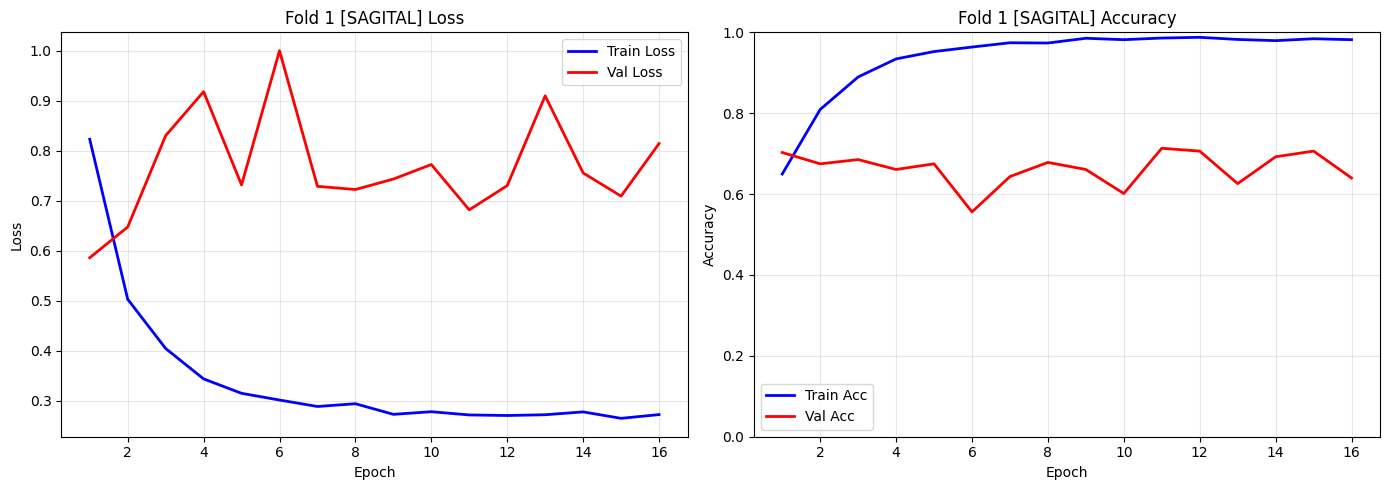


FOLD 1 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7028
  Precision     : 0.7174
  Recall        : 0.7028
  F1 Score      : 0.6963
  Per-Class F1  : CN=0.6473 | EMCI=0.7432 | Fark=0.0959 Normal
  Best Val Loss : 0.5861
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital/sagital_fold_1.pth

FOLD 2 [SAGITAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.7541 | Train Acc: 0.6694 | Val Loss: 0.9853 | Val Acc: 0.6259 | LR_bb: 5.00e-04
         Val tahmin: CN=264, EMCI=14
  Epoch 02 * | Train Loss: 0.4875 | Train Acc: 0.8300 | Val Loss: 0.9194 | Val Acc: 0.6223 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4088 | Train A

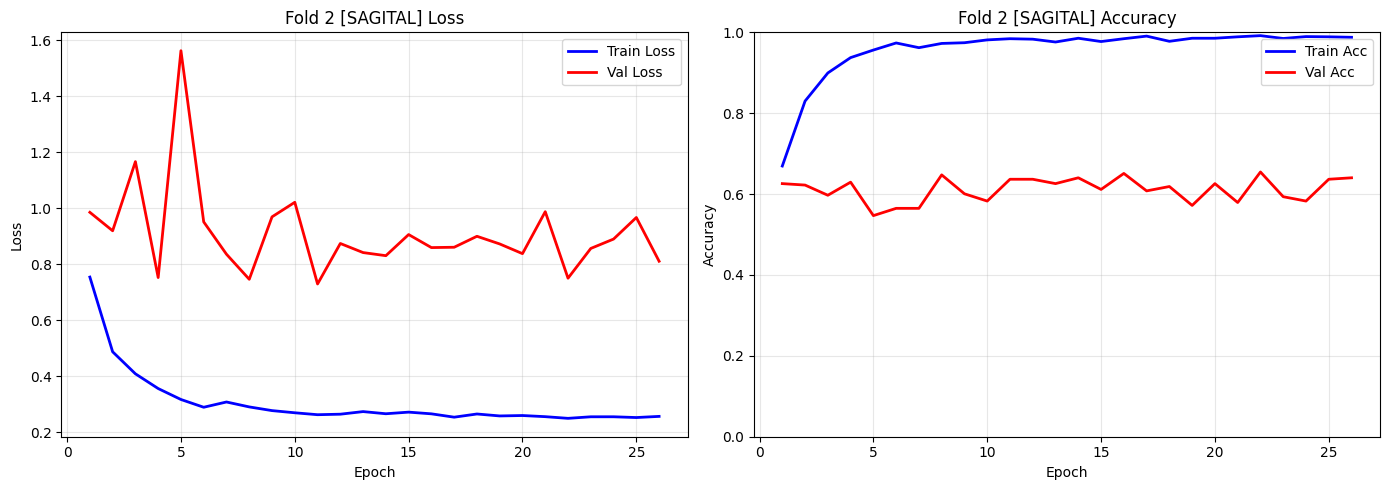


FOLD 2 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6367
  Precision     : 0.6291
  Recall        : 0.6367
  F1 Score      : 0.6195
  Per-Class F1  : CN=0.7218 | EMCI=0.4767 | Fark=0.2451 KONTROL ET
  Best Val Loss : 0.7294
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital/sagital_fold_2.pth

FOLD 3 [SAGITAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.7731 | Train Acc: 0.6533 | Val Loss: 0.7123 | Val Acc: 0.6210 | LR_bb: 5.00e-04
         Val tahmin: CN=178, EMCI=136
  Epoch 02   | Train Loss: 0.5294 | Train Acc: 0.8007 | Val Loss: 0.8438 | Val Acc: 0.6083 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4155 | Tr

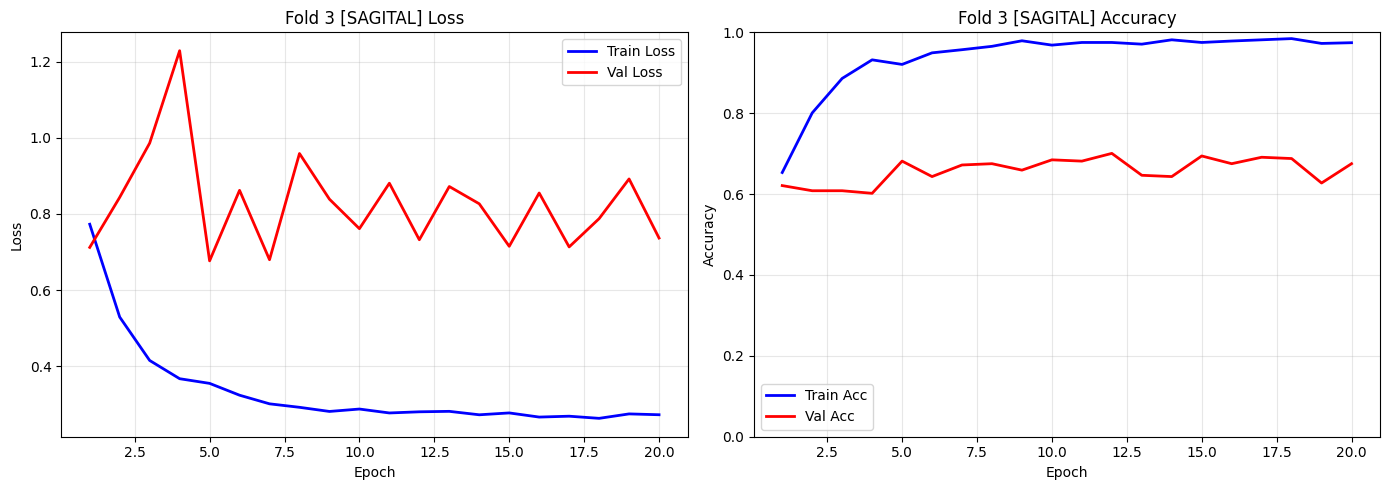


FOLD 3 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6815
  Precision     : 0.6799
  Recall        : 0.6815
  F1 Score      : 0.6800
  Per-Class F1  : CN=0.7222 | EMCI=0.6269 | Fark=0.0954 Normal
  Best Val Loss : 0.6770
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital/sagital_fold_3.pth

FOLD 4 [SAGITAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.7496 | Train Acc: 0.6549 | Val Loss: 0.6505 | Val Acc: 0.6574 | LR_bb: 5.00e-04
         Val tahmin: CN=124, EMCI=165
  Epoch 02 * | Train Loss: 0.5246 | Train Acc: 0.7931 | Val Loss: 0.6245 | Val Acc: 0.7093 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4482 | Train 

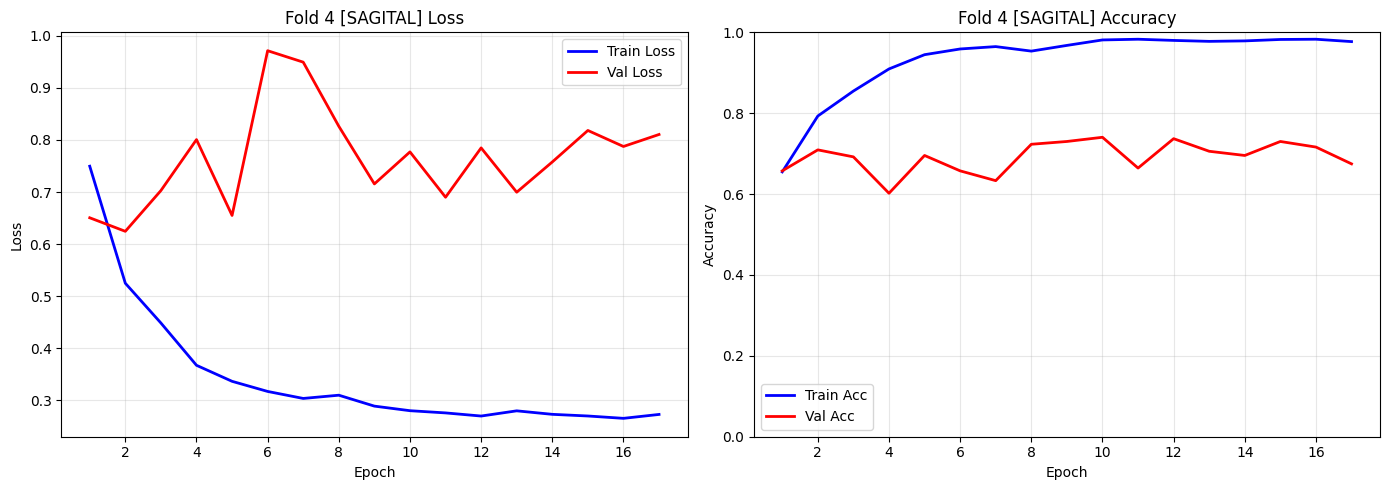


FOLD 4 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.7093
  Precision     : 0.7134
  Recall        : 0.7093
  F1 Score      : 0.7097
  Per-Class F1  : CN=0.7162 | EMCI=0.7021 | Fark=0.0141 Normal
  Best Val Loss : 0.6245
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital/sagital_fold_4.pth

FOLD 5 [SAGITAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[SAGITAL] Toplam param   : 7,216,770
[SAGITAL] Egitilen param : 2,423,042 (33.58%)
[SAGITAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.8529 | Train Acc: 0.6371 | Val Loss: 0.6668 | Val Acc: 0.6703 | LR_bb: 5.00e-04
         Val tahmin: CN=63, EMCI=213
  Epoch 02   | Train Loss: 0.5328 | Train Acc: 0.7940 | Val Loss: 0.9245 | Val Acc: 0.6884 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4048 | Train A

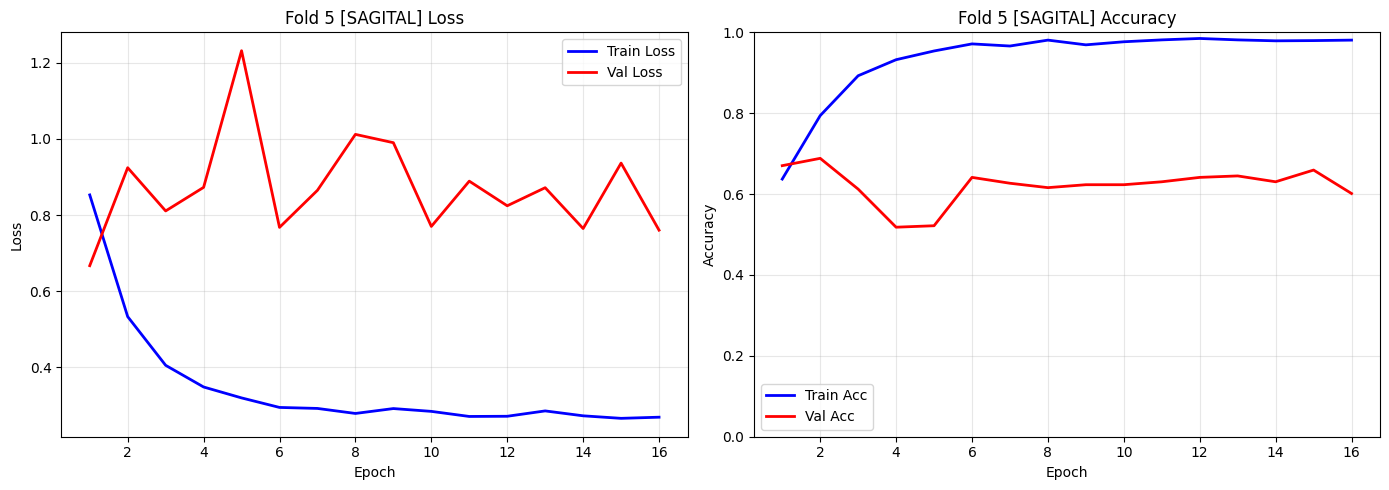


FOLD 5 VALIDATION SONUCLARI [SAGITAL]
  Val Accuracy  : 0.6703
  Precision     : 0.6863
  Recall        : 0.6703
  F1 Score      : 0.6444
  Per-Class F1  : CN=0.5027 | EMCI=0.7534 | Fark=0.2507 KONTROL ET
  Best Val Loss : 0.6668
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital/sagital_fold_5.pth

SAGITAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.702797 0.696259       0.586088
    2 0.636691 0.619500       0.729436
    3 0.681529 0.680010       0.677008
    4 0.709343 0.709684       0.624463
    5 0.670290 0.644407       0.666811
Ortalama Val Acc: 0.6801 +/- 0.0290
Sure: 27.7 dakika


In [ ]:
import time

sagital_klasoru = os.path.join(ANA_KLASOR, "Sagital")

print(f"EGITIM 1/3: SAGITAL")
print(f"Klasor: {sagital_klasoru}\n")

t0 = time.time()
sonuclar_sagital = duzlem_egit(tum_veriler, 'sagital', CONFIG, sagital_klasoru)
sure_sagital = time.time() - t0

df_sagital = pd.read_csv(os.path.join(sagital_klasoru, 'deney_sonuclari.csv'))
print(f"\nSAGITAL 5-FOLD VALIDATION SONUCLARI:")
print(df_sagital[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_sagital['val_acc'].mean():.4f} +/- {df_sagital['val_acc'].std():.4f}")
print(f"Sure: {sure_sagital/60:.1f} dakika")

EGITIM 2/3: AKSIYAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Aksiyal


DUZLEM: AKSIYAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Aksiyal

FOLD 1 [AKSIYAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.8531 | Train Acc: 0.6174 | Val Loss: 0.7324 | Val Acc: 0.5909 | LR_bb: 5.00e-04
         Val tahmin: CN=183, EMCI=103
  Epoch 02   | Train Loss: 0.5615 | Train Acc: 0.7482 | Val Loss: 0.8366 | Val Acc: 0.5874 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4748 | Train Acc: 0.8392 | Val Loss: 0.8034 | Val Acc: 0.5874 | LR_bb: 4.99e-04
  Epoch 04 * | Trai

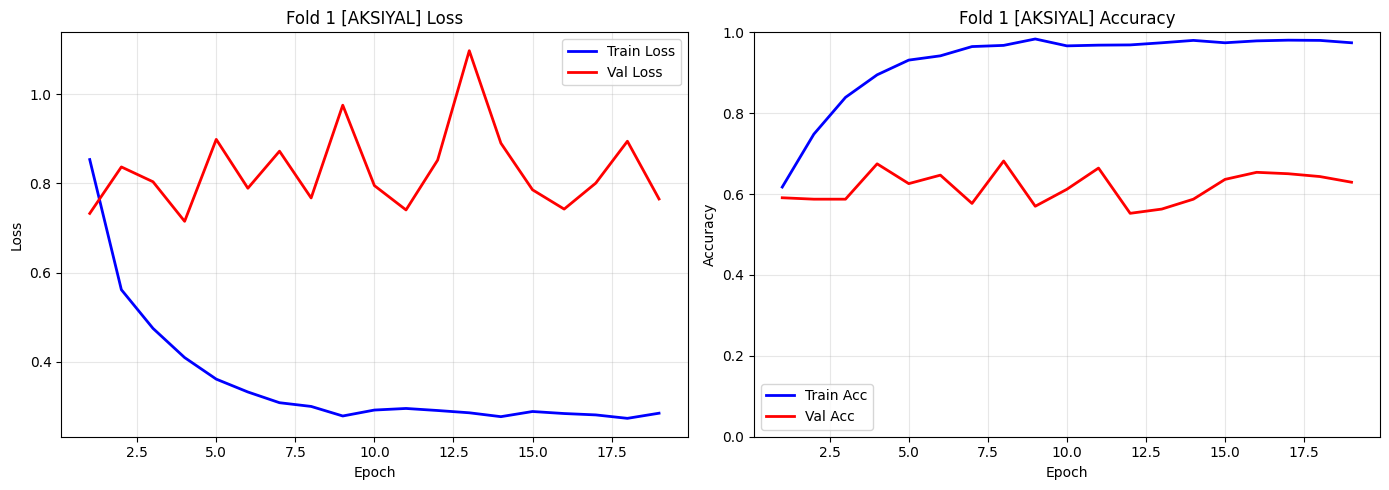


FOLD 1 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6748
  Precision     : 0.6750
  Recall        : 0.6748
  F1 Score      : 0.6749
  Per-Class F1  : CN=0.6714 | EMCI=0.6782 | Fark=0.0068 Normal
  Best Val Loss : 0.7148
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Aksiyal/aksiyal_fold_1.pth

FOLD 2 [AKSIYAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.8034 | Train Acc: 0.6472 | Val Loss: 0.7567 | Val Acc: 0.5827 | LR_bb: 5.00e-04
         Val tahmin: CN=190, EMCI=88
  Epoch 02   | Train Loss: 0.4936 | Train Acc: 0.8178 | Val Loss: 0.9629 | Val Acc: 0.5396 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4160 | Train A

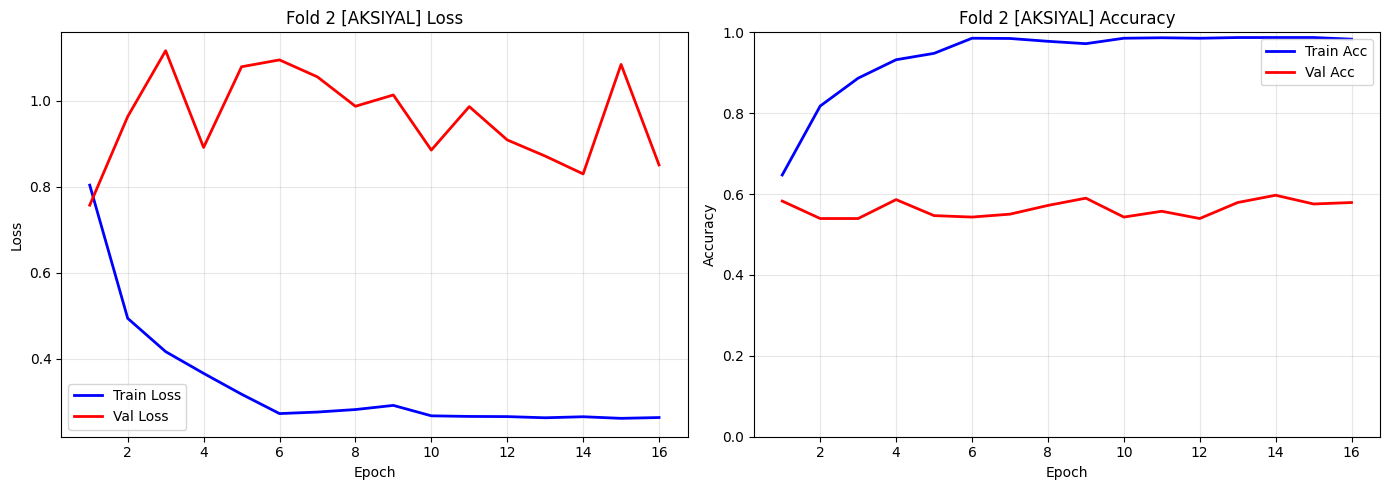


FOLD 2 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.5827
  Precision     : 0.5705
  Recall        : 0.5827
  F1 Score      : 0.5707
  Per-Class F1  : CN=0.6705 | EMCI=0.4314 | Fark=0.2391 KONTROL ET
  Best Val Loss : 0.7567
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Aksiyal/aksiyal_fold_2.pth

FOLD 3 [AKSIYAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.7594 | Train Acc: 0.6158 | Val Loss: 0.5859 | Val Acc: 0.6656 | LR_bb: 5.00e-04
         Val tahmin: CN=214, EMCI=100
  Epoch 02   | Train Loss: 0.5333 | Train Acc: 0.7673 | Val Loss: 0.7079 | Val Acc: 0.6561 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4775 | Tr

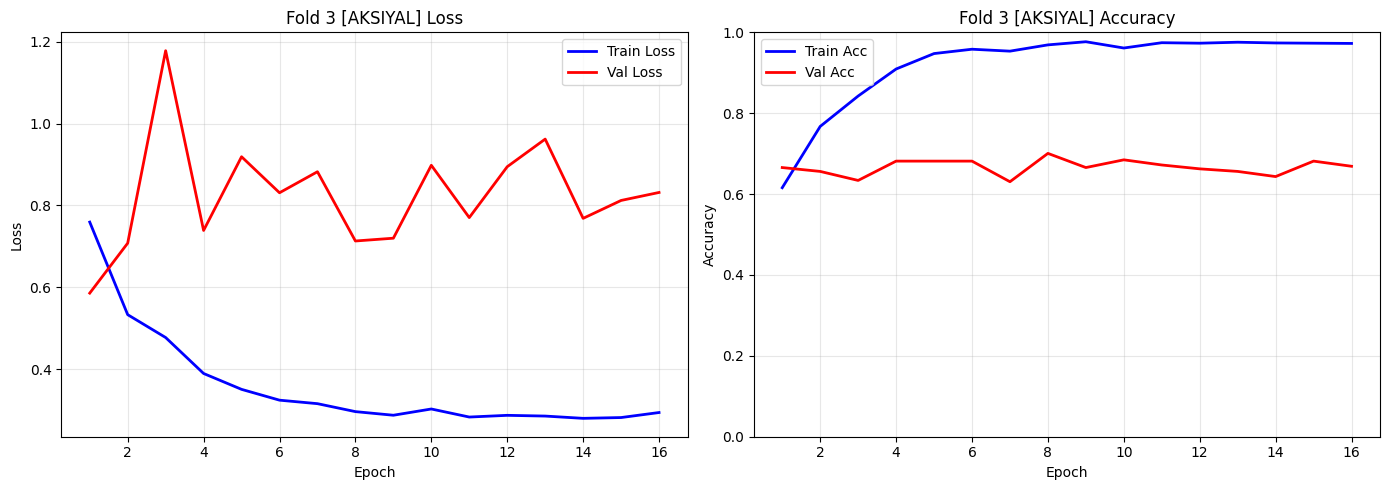


FOLD 3 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6656
  Precision     : 0.6664
  Recall        : 0.6656
  F1 Score      : 0.6551
  Per-Class F1  : CN=0.7301 | EMCI=0.5607 | Fark=0.1694 KONTROL ET
  Best Val Loss : 0.5859
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Aksiyal/aksiyal_fold_3.pth

FOLD 4 [AKSIYAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.8334 | Train Acc: 0.6361 | Val Loss: 0.6387 | Val Acc: 0.6713 | LR_bb: 5.00e-04
         Val tahmin: CN=84, EMCI=205
  Epoch 02   | Train Loss: 0.5614 | Train Acc: 0.7719 | Val Loss: 0.7805 | Val Acc: 0.6886 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4555 | Tra

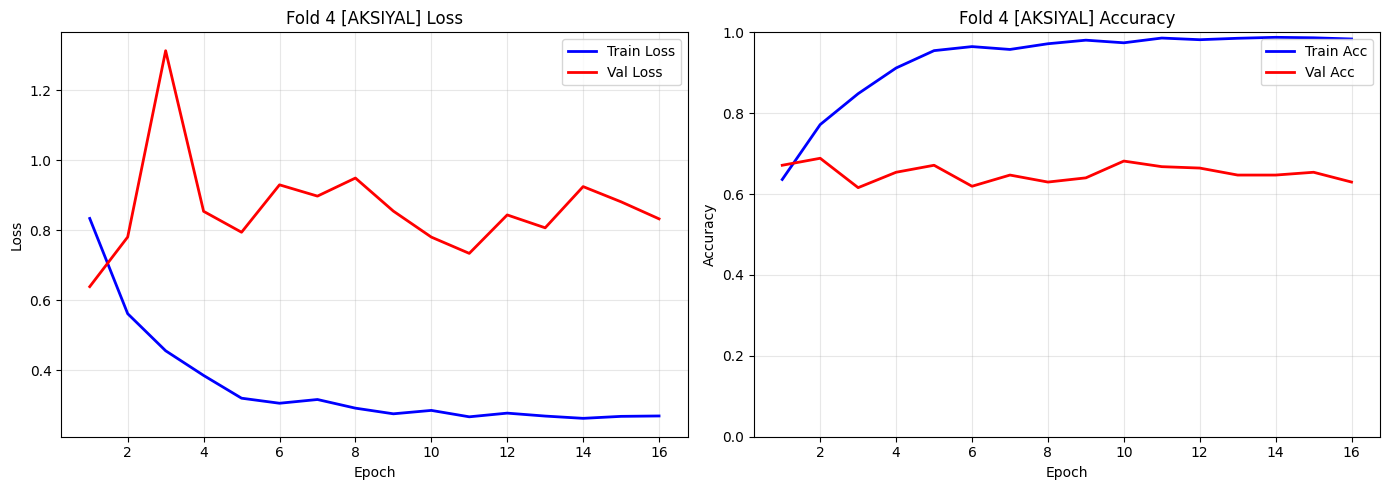


FOLD 4 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6713
  Precision     : 0.7357
  Recall        : 0.6713
  F1 Score      : 0.6569
  Per-Class F1  : CN=0.6025 | EMCI=0.7198 | Fark=0.1173 KONTROL ET
  Best Val Loss : 0.6387
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Aksiyal/aksiyal_fold_4.pth

FOLD 5 [AKSIYAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[AKSIYAL] Toplam param   : 7,216,770
[AKSIYAL] Egitilen param : 2,423,042 (33.58%)
[AKSIYAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.7976 | Train Acc: 0.6225 | Val Loss: 0.6750 | Val Acc: 0.6268 | LR_bb: 5.00e-04
         Val tahmin: CN=139, EMCI=137
  Epoch 02 * | Train Loss: 0.5856 | Train Acc: 0.7252 | Val Loss: 0.6448 | Val Acc: 0.6522 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4780 | Tr

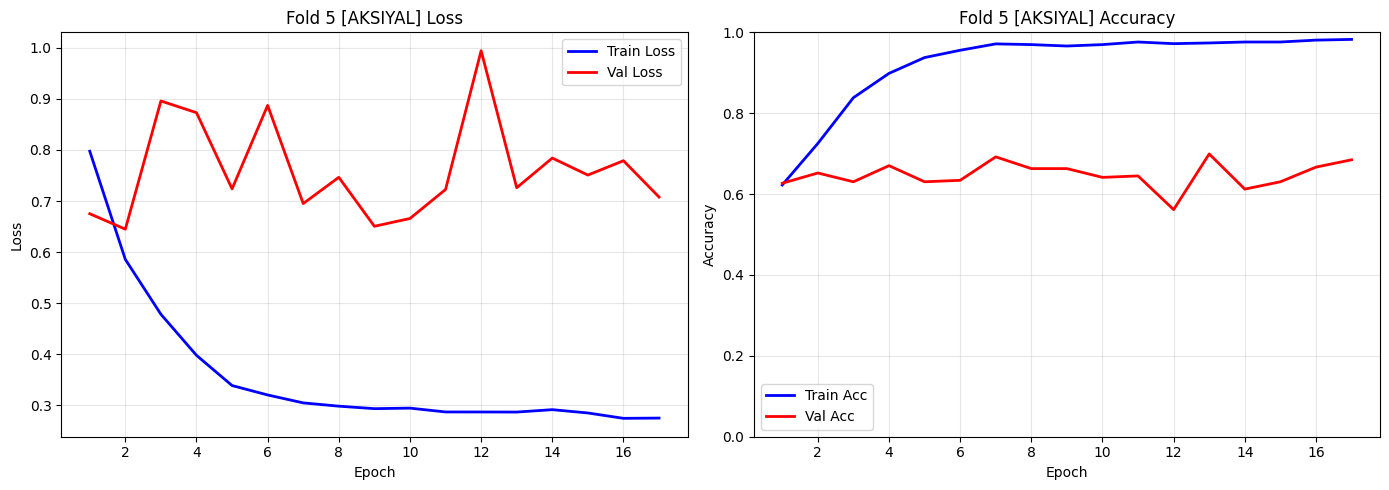


FOLD 5 VALIDATION SONUCLARI [AKSIYAL]
  Val Accuracy  : 0.6522
  Precision     : 0.6760
  Recall        : 0.6522
  F1 Score      : 0.6145
  Per-Class F1  : CN=0.4419 | EMCI=0.7474 | Fark=0.3055 KONTROL ET
  Best Val Loss : 0.6448
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Aksiyal/aksiyal_fold_5.pth

AKSIYAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.674825 0.674861       0.714762
    2 0.582734 0.570694       0.756730
    3 0.665605 0.655085       0.585909
    4 0.671280 0.656877       0.638661
    5 0.652174 0.614539       0.644793
Ortalama Val Acc: 0.6493 +/- 0.0382
Sure: 24.6 dakika


In [ ]:
import time

aksiyal_klasoru = os.path.join(ANA_KLASOR, "Aksiyal")

print(f"EGITIM 2/3: AKSIYAL")
print(f"Klasor: {aksiyal_klasoru}\n")

t0 = time.time()
sonuclar_aksiyal = duzlem_egit(tum_veriler, 'aksiyal', CONFIG, aksiyal_klasoru)
sure_aksiyal = time.time() - t0

df_aksiyal = pd.read_csv(os.path.join(aksiyal_klasoru, 'deney_sonuclari.csv'))
print(f"\nAKSIYAL 5-FOLD VALIDATION SONUCLARI:")
print(df_aksiyal[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_aksiyal['val_acc'].mean():.4f} +/- {df_aksiyal['val_acc'].std():.4f}")
print(f"Sure: {sure_aksiyal/60:.1f} dakika")

EGITIM 3/3: KORONAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Koronal


DUZLEM: KORONAL
Klasor: /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Koronal

FOLD 1 [KORONAL]
  Train: 396 hasta / 1704 seans
  Val  : 70 hasta / 286 seans
  Train: CN=903 (53.0%) | EMCI=801 (47.0%)
  Val: CN=140 (49.0%) | EMCI=146 (51.0%)
Class Weights: CN=0.944, EMCI=1.064
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.7674 | Train Acc: 0.6444 | Val Loss: 0.6217 | Val Acc: 0.6399 | LR_bb: 5.00e-04
         Val tahmin: CN=85, EMCI=201
  Epoch 02   | Train Loss: 0.5412 | Train Acc: 0.7682 | Val Loss: 0.8403 | Val Acc: 0.6049 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4618 | Train Acc: 0.8568 | Val Loss: 0.7402 | Val Acc: 0.6364 | LR_bb: 4.99e-04
  Epoch 04   | Train

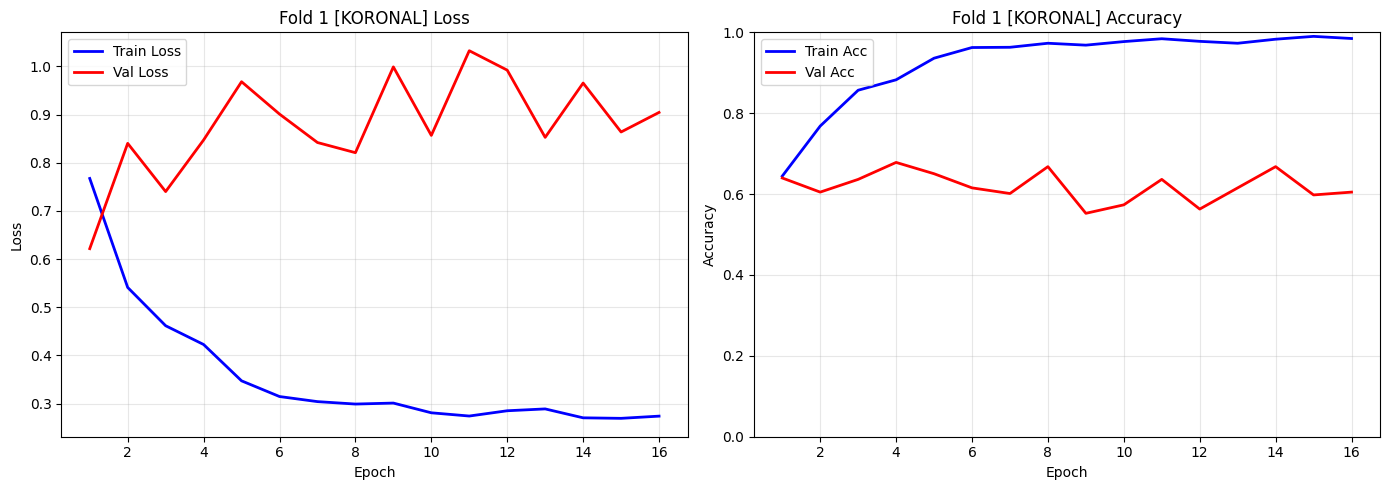


FOLD 1 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6399
  Precision     : 0.6611
  Recall        : 0.6399
  F1 Score      : 0.6244
  Per-Class F1  : CN=0.5422 | EMCI=0.7032 | Fark=0.1609 KONTROL ET
  Best Val Loss : 0.6217
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Koronal/koronal_fold_1.pth

FOLD 2 [KORONAL]
  Train: 396 hasta / 1712 seans
  Val  : 70 hasta / 278 seans
  Train: CN=881 (51.5%) | EMCI=831 (48.5%)
  Val: CN=162 (58.3%) | EMCI=116 (41.7%)
Class Weights: CN=0.972, EMCI=1.030
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.7399 | Train Acc: 0.6542 | Val Loss: 0.6767 | Val Acc: 0.5971 | LR_bb: 5.00e-04
         Val tahmin: CN=250, EMCI=28
  Epoch 02 * | Train Loss: 0.5358 | Train Acc: 0.7833 | Val Loss: 0.6629 | Val Acc: 0.6655 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4287 | Tra

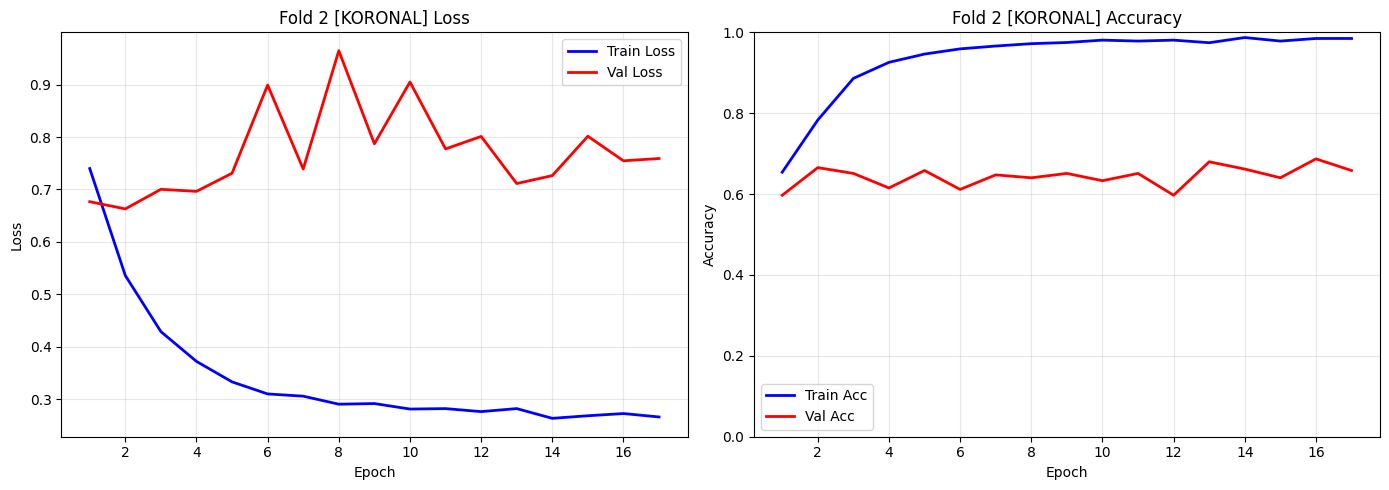


FOLD 2 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6655
  Precision     : 0.6709
  Recall        : 0.6655
  F1 Score      : 0.6672
  Per-Class F1  : CN=0.7029 | EMCI=0.6173 | Fark=0.0856 Normal
  Best Val Loss : 0.6629
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Koronal/koronal_fold_2.pth

FOLD 3 [KORONAL]
  Train: 396 hasta / 1676 seans
  Val  : 70 hasta / 314 seans
  Train: CN=868 (51.8%) | EMCI=808 (48.2%)
  Val: CN=175 (55.7%) | EMCI=139 (44.3%)
Class Weights: CN=0.965, EMCI=1.037
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.7785 | Train Acc: 0.6205 | Val Loss: 0.6082 | Val Acc: 0.6115 | LR_bb: 5.00e-04
         Val tahmin: CN=157, EMCI=157
  Epoch 02   | Train Loss: 0.5685 | Train Acc: 0.7494 | Val Loss: 0.6999 | Val Acc: 0.6624 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4827 | Train 

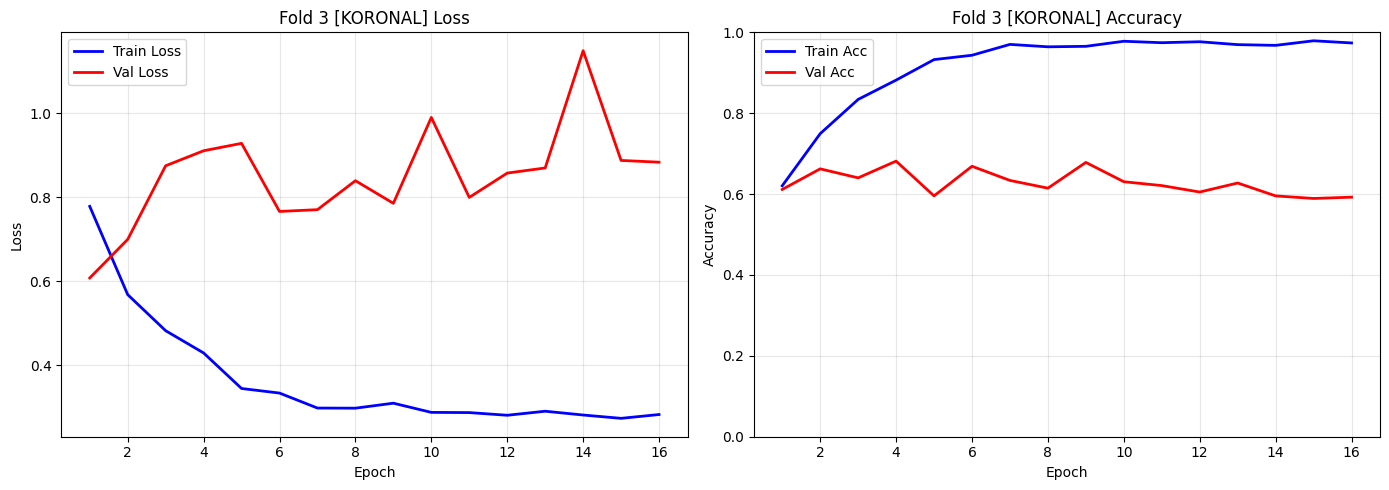


FOLD 3 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6115
  Precision     : 0.6180
  Recall        : 0.6115
  F1 Score      : 0.6127
  Per-Class F1  : CN=0.6325 | EMCI=0.5878 | Fark=0.0447 Normal
  Best Val Loss : 0.6082
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Koronal/koronal_fold_3.pth

FOLD 4 [KORONAL]
  Train: 396 hasta / 1701 seans
  Val  : 70 hasta / 289 seans
  Train: CN=888 (52.2%) | EMCI=813 (47.8%)
  Val: CN=155 (53.6%) | EMCI=134 (46.4%)
Class Weights: CN=0.958, EMCI=1.046
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.7837 | Train Acc: 0.6249 | Val Loss: 0.6368 | Val Acc: 0.6644 | LR_bb: 5.00e-04
         Val tahmin: CN=74, EMCI=215
  Epoch 02   | Train Loss: 0.5588 | Train Acc: 0.7737 | Val Loss: 0.7850 | Val Acc: 0.5848 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4672 | Train A

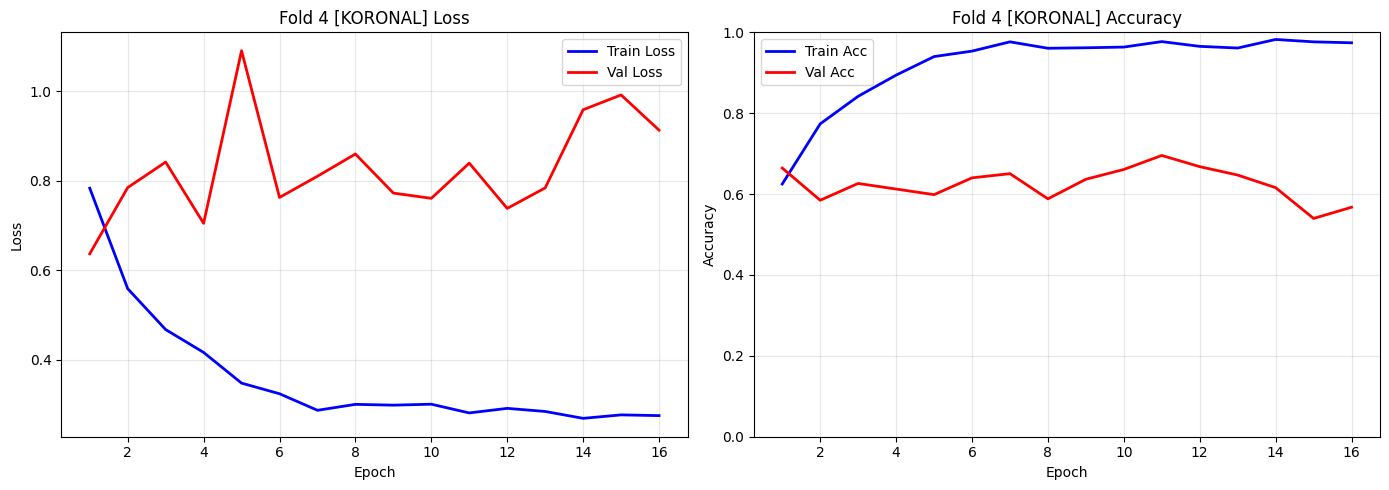


FOLD 4 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.6644
  Precision     : 0.7501
  Recall        : 0.6644
  F1 Score      : 0.6439
  Per-Class F1  : CN=0.5764 | EMCI=0.7221 | Fark=0.1456 KONTROL ET
  Best Val Loss : 0.6368
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Koronal/koronal_fold_4.pth

FOLD 5 [KORONAL]
  Train: 396 hasta / 1714 seans
  Val  : 70 hasta / 276 seans
  Train: CN=923 (53.9%) | EMCI=791 (46.1%)
  Val: CN=120 (43.5%) | EMCI=156 (56.5%)
Class Weights: CN=0.928, EMCI=1.083
[KORONAL] Toplam param   : 7,216,770
[KORONAL] Egitilen param : 2,423,042 (33.58%)
[KORONAL] Dropout        : 0.5
  Epoch 01 * | Train Loss: 0.8016 | Train Acc: 0.6074 | Val Loss: 0.7605 | Val Acc: 0.7210 | LR_bb: 5.00e-04
         Val tahmin: CN=95, EMCI=181
  Epoch 02 * | Train Loss: 0.5676 | Train Acc: 0.7631 | Val Loss: 0.7213 | Val Acc: 0.6812 | LR_bb: 5.00e-04
  Epoch 03   | Train Loss: 0.4890 | Tra

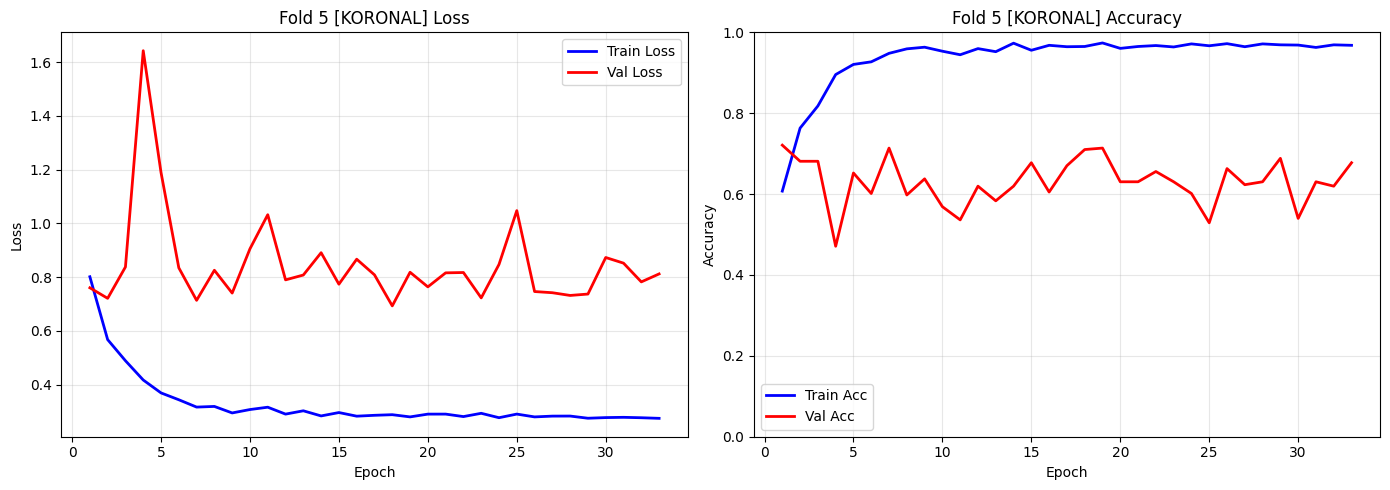


FOLD 5 VALIDATION SONUCLARI [KORONAL]
  Val Accuracy  : 0.7101
  Precision     : 0.7340
  Recall        : 0.7101
  F1 Score      : 0.6895
  Per-Class F1  : CN=0.5699 | EMCI=0.7814 | Fark=0.2115 KONTROL ET
  Best Val Loss : 0.6932
  Model kaydi   : /content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Koronal/koronal_fold_5.pth

KORONAL 5-FOLD VALIDATION SONUCLARI:
 fold  val_acc   val_f1  best_val_loss
    1 0.639860 0.624384       0.621745
    2 0.665468 0.667161       0.662872
    3 0.611465 0.612746       0.608155
    4 0.664360 0.643950       0.636812
    5 0.710145 0.689452       0.693182
Ortalama Val Acc: 0.6583 +/- 0.0364
Sure: 28.3 dakika


In [ ]:
import time

koronal_klasoru = os.path.join(ANA_KLASOR, "Koronal")

print(f"EGITIM 3/3: KORONAL")
print(f"Klasor: {koronal_klasoru}\n")

t0 = time.time()
sonuclar_koronal = duzlem_egit(tum_veriler, 'koronal', CONFIG, koronal_klasoru)
sure_koronal = time.time() - t0

df_koronal = pd.read_csv(os.path.join(koronal_klasoru, 'deney_sonuclari.csv'))
print(f"\nKORONAL 5-FOLD VALIDATION SONUCLARI:")
print(df_koronal[['fold', 'val_acc', 'val_f1', 'best_val_loss']].to_string(index=False))
print(f"Ortalama Val Acc: {df_koronal['val_acc'].mean():.4f} +/- {df_koronal['val_acc'].std():.4f}")
print(f"Sure: {sure_koronal/60:.1f} dakika")

TOPLU VALIDATION SONUCLARI (Per-Plane)

--- SAGITAL ---
 fold  val_acc   val_f1  val_f1_cn  val_f1_emci  best_val_loss
    1 0.702797 0.696259   0.647303     0.743202       0.586088
    2 0.636691 0.619500   0.721763     0.476684       0.729436
    3 0.681529 0.680010   0.722222     0.626866       0.677008
    4 0.709343 0.709684   0.716216     0.702128       0.624463
    5 0.670290 0.644407   0.502732     0.753388       0.666811
  Ortalama Val Acc : 0.6801 +/- 0.0290
  Ortalama Val F1  : 0.6700
  CN F1 / EMCI F1  : 0.6620 / 0.6605

--- AKSIYAL ---
 fold  val_acc   val_f1  val_f1_cn  val_f1_emci  best_val_loss
    1 0.674825 0.674861   0.671378     0.678201       0.714762
    2 0.582734 0.570694   0.670455     0.431373       0.756730
    3 0.665605 0.655085   0.730077     0.560669       0.585909
    4 0.671280 0.656877   0.602510     0.719764       0.638661
    5 0.652174 0.614539   0.441860     0.747368       0.644793
  Ortalama Val Acc : 0.6493 +/- 0.0382
  Ortalama Val F1  : 0.6344


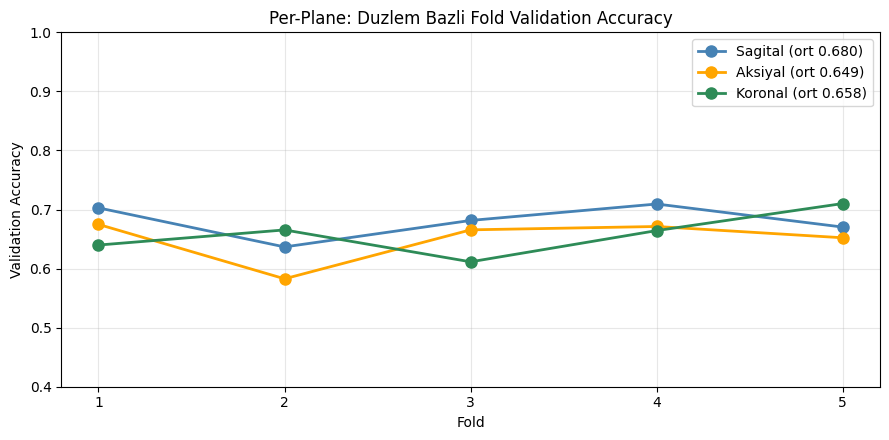

In [ ]:
# ===== TOPLU VALIDATION OZETI (3 duzlem x 5 fold) =====
import pandas as pd, os

# Modeller baska bir oturumda egitildiyse ANA_KLASOR'u elle sabitle:

duzlemler = {
    'Sagital': os.path.join(ANA_KLASOR, 'Sagital', 'deney_sonuclari.csv'),
    'Aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal', 'deney_sonuclari.csv'),
    'Koronal': os.path.join(ANA_KLASOR, 'Koronal', 'deney_sonuclari.csv'),
}

tum_dfler = []
print("="*70)
print("TOPLU VALIDATION SONUCLARI (Per-Plane)")
print("="*70)

for ad, yol in duzlemler.items():
    if not os.path.exists(yol):
        print(f"\n[{ad}] CSV bulunamadi ({yol}) - bu duzlem egitilmemis olabilir.")
        continue
    df = pd.read_csv(yol)
    df['duzlem'] = ad
    tum_dfler.append(df)

    print(f"\n--- {ad.upper()} ---")
    print(df[['fold', 'val_acc', 'val_f1', 'val_f1_cn', 'val_f1_emci', 'best_val_loss']].to_string(index=False))
    print(f"  Ortalama Val Acc : {df['val_acc'].mean():.4f} +/- {df['val_acc'].std():.4f}")
    print(f"  Ortalama Val F1  : {df['val_f1'].mean():.4f}")
    print(f"  CN F1 / EMCI F1  : {df['val_f1_cn'].mean():.4f} / {df['val_f1_emci'].mean():.4f}")

if tum_dfler:
    hepsi = pd.concat(tum_dfler, ignore_index=True)

    print("\n" + "="*70)
    print("DUZLEM BAZLI OZET TABLOSU")
    print("="*70)
    ozet = hepsi.groupby('duzlem').agg(
        val_acc_ort=('val_acc', 'mean'),
        val_acc_std=('val_acc', 'std'),
        val_f1_ort=('val_f1', 'mean'),
        cn_f1=('val_f1_cn', 'mean'),
        emci_f1=('val_f1_emci', 'mean'),
    ).round(4)
    print(ozet.to_string())

    print("\n" + "="*70)
    print("GENEL ORTALAMA (15 model = 3 duzlem x 5 fold)")
    print("="*70)
    print(f"  Val Accuracy : {hepsi['val_acc'].mean():.4f} +/- {hepsi['val_acc'].std():.4f}")
    print(f"  Val F1       : {hepsi['val_f1'].mean():.4f} +/- {hepsi['val_f1'].std():.4f}")
    print(f"  CN F1        : {hepsi['val_f1_cn'].mean():.4f}")
    print(f"  EMCI F1      : {hepsi['val_f1_emci'].mean():.4f}")

    # Gorsel: duzlem bazli fold accuracy
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 4.5))
    renkler = {'Sagital': 'steelblue', 'Aksiyal': 'orange', 'Koronal': 'seagreen'}
    for ad in ['Sagital', 'Aksiyal', 'Koronal']:
        d = hepsi[hepsi['duzlem'] == ad]
        if len(d) == 0: continue
        ax.plot(d['fold'], d['val_acc'], 'o-', label=f"{ad} (ort {d['val_acc'].mean():.3f})",
                color=renkler[ad], lw=2, markersize=8)
    ax.set_xlabel('Fold'); ax.set_ylabel('Validation Accuracy')
    ax.set_title('Per-Plane: Duzlem Bazli Fold Validation Accuracy')
    ax.set_xticks([1,2,3,4,5]); ax.set_ylim([0.4, 1.0])
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(ANA_KLASOR, 'toplu_val_accuracy.png'), dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("\nHic CSV bulunamadi. Once egitimi calistir veya ANA_KLASOR'u dogru klasore sabitle.")

## NIHAI TEST — Izole Test Seti + Agirlikli Ensemble

Asagidaki hucre, egitime HIC girmemis izole test setini okur, kaydedilen
15 modeli (3 duzlem x 5 fold) yukler ve **agirlikli soft voting** ile
tek bir nihai tahmin uretir.

`DUZLEM_AGIRLIK` sozlugu ile her duzleme verilen agirligi degistirebilirsin.
Su an hepsi esit. Ornegin aksiyali zayiflatmak istersen:
`{'sagital': 1.0, 'aksiyal': 0.5, 'koronal': 1.0}` yapabilirsin.


TEST seti: 296 seans  (CN=148, EMCI=148)

[SAGITAL] 5 fold modeli test ediliyor...
  fold 1 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital/sagital_fold_1.pth)
  fold 2 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital/sagital_fold_2.pth)
  fold 3 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital/sagital_fold_3.pth)
  fold 4 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital/sagital_fold_4.pth)
  fold 5 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32/Sagital/sagital_fold_5.pth)

[AKSIYAL] 5 fold modeli test ediliyor...
  fold 1 tamam (/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Da

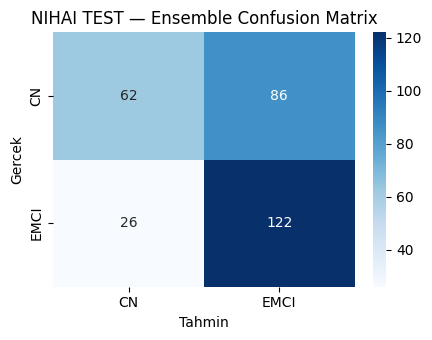

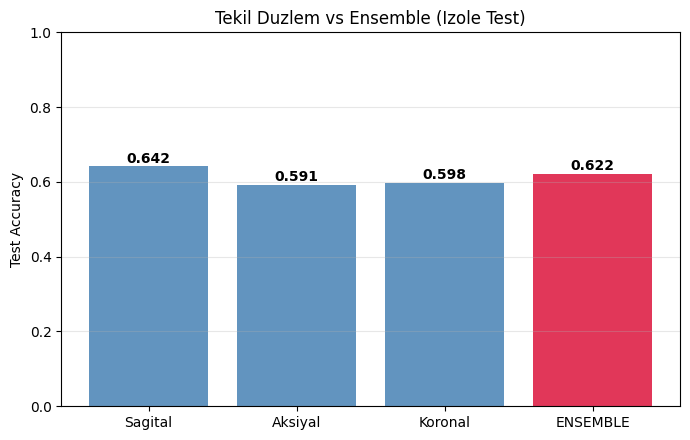


Kaydedildi: final_test_tahminler.csv, final_test_ozet.csv
Bitti.


In [ ]:
# ============================================================
# NIHAI TEST: izole test seti + 15 model agirlikli ensemble
# ============================================================
import numpy as np
ANA_KLASOR = '/content/drive/MyDrive/GizemZor/YAZILIM_TASARIMI/Bitirme/Dataset/models/DenseNet_PerPlane_Ensemble_2026_06_04_19_32'


# --- 1) Izole test verisini oku (train ile AYNI yapida) ---
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]

test_veriler = veri_listesi_olustur(test_config)
n_cn_te   = sum(1 for x in test_veriler if x['etiket'] == 0)
n_emci_te = sum(1 for x in test_veriler if x['etiket'] == 1)
print(f"TEST seti: {len(test_veriler)} seans  (CN={n_cn_te}, EMCI={n_emci_te})")
assert len(test_veriler) > 0, "Test seti bos! kaynak_CN_test / kaynak_EMCI_test yollarini kontrol et."

# Gercek etiket sozlugu: sid -> etiket
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# --- 2) Ensemble agirliklari (degistirilebilir) ---
DUZLEM_AGIRLIK = {'sagital': 1.0, 'aksiyal': 1.0, 'koronal': 1.0}

DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# --- 3) Tahmin yardimci fonksiyonu (seans_id ile birlikte) ---
def tahmin_al(model, loader):
    model.eval()
    sids_all, probs_all = [], []
    with torch.no_grad():
        for sids, slices, lbls in loader:
            slices = slices.to(DEVICE)
            logits = model(slices)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            sids_all.extend(list(sids))
            probs_all.extend(probs.tolist())
    return sids_all, probs_all

# --- 4) Her duzlem icin 5 fold modelin olasiligini ortala ---
# plane_avg[duzlem][sid] = ortalama [prob_cn, prob_emci]
plane_avg = {}

for duzlem, klasor in DUZLEM_KLASOR.items():
    print(f"\n[{duzlem.upper()}] 5 fold modeli test ediliyor...")
    test_loader = loader_olustur(test_veriler, duzlem, CONFIG, shuffle=False)

    toplam = {}   # sid -> np.array([p_cn, p_emci]) toplam
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{duzlem}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        for sid, pr in zip(sids, probs):
            toplam.setdefault(sid, np.zeros(2))
            toplam[sid] += np.array(pr)
        print(f"  fold {fold} tamam ({m_path})")
        del model
        torch.cuda.empty_cache()

    plane_avg[duzlem] = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# --- 5) Agirlikli ensemble (3 duzlem) ---
toplam_agirlik = sum(DUZLEM_AGIRLIK.values())
ortak_sid = set.intersection(*[set(plane_avg[d].keys()) for d in DUZLEM_KLASOR])
print(f"\nUc duzlemde de tahmin edilen ortak seans: {len(ortak_sid)}")

y_true, y_pred = [], []
y_pred_duzlem = {d: [] for d in DUZLEM_KLASOR}
kayit = []

for sid in sorted(ortak_sid):
    fused = np.zeros(2)
    for d in DUZLEM_KLASOR:
        fused += DUZLEM_AGIRLIK[d] * plane_avg[d][sid]
    fused /= toplam_agirlik

    pred = int(np.argmax(fused))
    true = sid_true[sid]
    y_true.append(true)
    y_pred.append(pred)

    satir = {'seans_id': sid,
             'gercek': 'CN' if true == 0 else 'EMCI',
             'ens_prob_cn': fused[0], 'ens_prob_emci': fused[1],
             'ensemble': 'CN' if pred == 0 else 'EMCI'}
    for d in DUZLEM_KLASOR:
        dp = int(np.argmax(plane_avg[d][sid]))
        y_pred_duzlem[d].append(dp)
        satir[d] = 'CN' if dp == 0 else 'EMCI'
    satir['dogru_mu'] = (true == pred)
    kayit.append(satir)

# --- 6) Metrikler ---
acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=[0, 1], zero_division=0
)

print(f"\n{'='*70}")
print("NIHAI TEST SONUCLARI (Agirlikli Ensemble)")
print(f"{'='*70}")
print(f"Agirliklar    : {DUZLEM_AGIRLIK}")
print(f"Test seans    : {len(y_true)}")
print(f"\nTekil duzlem test accuracy:")
for d in DUZLEM_KLASOR:
    print(f"  {d.capitalize():9s}: {accuracy_score(y_true, y_pred_duzlem[d]):.4f}")
print(f"\n  ENSEMBLE Accuracy : {acc:.4f}")
print(f"  Precision         : {p:.4f}")
print(f"  Recall            : {r:.4f}")
print(f"  F1 Score          : {f:.4f}")
print(f"  Per-Class F1      : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")

print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

# --- 7) Confusion matrix ---
plt.figure(figsize=(4.5, 3.5))
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['CN', 'EMCI'], yticklabels=['CN', 'EMCI'])
plt.title("NIHAI TEST — Ensemble Confusion Matrix")
plt.xlabel("Tahmin"); plt.ylabel("Gercek")
plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'final_test_confusion_matrix.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# --- 8) Tekil duzlem vs ensemble grafigi ---
fig, axg = plt.subplots(figsize=(7, 4.5))
isimler = [d.capitalize() for d in DUZLEM_KLASOR] + ['ENSEMBLE']
degerler = [accuracy_score(y_true, y_pred_duzlem[d]) for d in DUZLEM_KLASOR] + [acc]
renkler = ['steelblue']*3 + ['crimson']
axg.bar(isimler, degerler, color=renkler, alpha=0.85)
for i, v in enumerate(degerler):
    axg.text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold')
axg.set_ylabel('Test Accuracy'); axg.set_ylim([0, 1])
axg.set_title('Tekil Duzlem vs Ensemble (Izole Test)')
axg.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ANA_KLASOR, 'final_test_karsilastirma.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# --- 9) Kayit ---
df_kayit = pd.DataFrame(kayit)
df_kayit.to_csv(os.path.join(ANA_KLASOR, 'final_test_tahminler.csv'), index=False)
pd.DataFrame([{
    'agirlik_sag': DUZLEM_AGIRLIK['sagital'],
    'agirlik_ax' : DUZLEM_AGIRLIK['aksiyal'],
    'agirlik_kor': DUZLEM_AGIRLIK['koronal'],
    'test_acc': acc, 'precision': p, 'recall': r, 'f1': f,
    'f1_cn': f_pc[0], 'f1_emci': f_pc[1], 'n_test': len(y_true)
}]).to_csv(os.path.join(ANA_KLASOR, 'final_test_ozet.csv'), index=False)

print(f"\nKaydedildi: final_test_tahminler.csv, final_test_ozet.csv")
print("Bitti.")

  Sagital   val_acc ort: 0.6801
  Aksiyal   val_acc ort: 0.6493
  Koronal   val_acc ort: 0.6583

VALIDATION'da en iyi duzlem: SAGITAL  (0.6801)

EN IYI DUZLEM (SAGITAL) 5-FOLD ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6419
   Precision    : 0.6457 | Recall: 0.6419 | F1: 0.6395
   Per-Class F1 : CN=0.6103 | EMCI=0.6687

              precision    recall  f1-score   support

          CN       0.67      0.56      0.61       148
        EMCI       0.62      0.72      0.67       148

    accuracy                           0.64       296
   macro avg       0.65      0.64      0.64       296
weighted avg       0.65      0.64      0.64       296



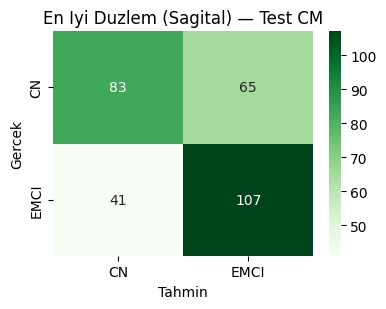

In [ ]:
# ===== EK HUCRE A: VALIDATION'da en iyi DUZLEMI sec, 5-fold ensemble test =====
import numpy as np, os

# Modeller baska oturumda egitildiyse dogru klasoru sabitle:
# ANA_KLASOR = '/content/drive/MyDrive/.../DenseNet_PerPlane_Ensemble_2026_06_04_19_32'

DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Her duzlemin VALIDATION ortalamasini oku, en iyisini sec (TEST'e gore DEGIL)
val_ort = {}
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    val_ort[d] = dfv['val_acc'].mean()
    print(f"  {d.capitalize():9s} val_acc ort: {val_ort[d]:.4f}")
en_iyi_duzlem = max(val_ort, key=val_ort.get)
print(f"\nVALIDATION'da en iyi duzlem: {en_iyi_duzlem.upper()}  ({val_ort[en_iyi_duzlem]:.4f})\n")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) Sadece o duzlemin 5 fold modelini ortala
klasor = DUZLEM_KLASOR[en_iyi_duzlem]
test_loader = loader_olustur(test_veriler, en_iyi_duzlem, CONFIG, shuffle=False)
toplam = {}
for fold in range(1, CONFIG['k_fold'] + 1):
    m_path = os.path.join(klasor, f'{en_iyi_duzlem}_fold_{fold}.pth')
    model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
    model.load_state_dict(torch.load(m_path, weights_only=True))
    sids, probs = tahmin_al(model, test_loader)
    for sid, pr in zip(sids, probs):
        toplam.setdefault(sid, np.zeros(2)); toplam[sid] += np.array(pr)
    del model; torch.cuda.empty_cache()
avg = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# 4) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(avg.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(avg[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"{'='*60}\nEN IYI DUZLEM ({en_iyi_duzlem.upper()}) 5-FOLD ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Greens',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title(f"En Iyi Duzlem ({en_iyi_duzlem.capitalize()}) — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()

Duzlem agirliklari (validation'dan):
   Sagital  : 0.369
   Aksiyal  : 0.306
   Koronal  : 0.324

VAL-AGIRLIKLI DUZLEM ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6284
   Precision    : 0.6517 | Recall: 0.6284 | F1: 0.6135
   Per-Class F1 : CN=0.5378 | EMCI=0.6893

              precision    recall  f1-score   support

          CN       0.71      0.43      0.54       148
        EMCI       0.59      0.82      0.69       148

    accuracy                           0.63       296
   macro avg       0.65      0.63      0.61       296
weighted avg       0.65      0.63      0.61       296



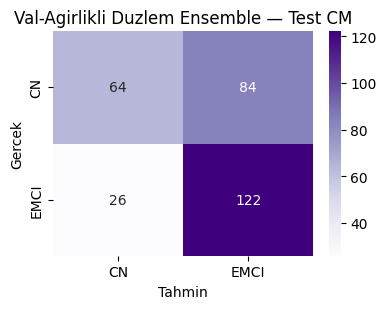

In [ ]:
# ===== EK HUCRE B: VALIDATION accuracy ile DUZLEM-AGIRLIKLI ensemble =====
import numpy as np, os

# ANA_KLASOR = '/content/drive/MyDrive/.../DenseNet_PerPlane_Ensemble_2026_06_04_19_32'

DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Agirliklar VALIDATION'dan: (val_acc - 0.5) ile zayif duzlem otomatik kisilir
agirlik = {}
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    agirlik[d] = max(dfv['val_acc'].mean() - 0.5, 0.0)
toplam_ag = sum(agirlik.values())
agirlik = {d: v / toplam_ag for d, v in agirlik.items()}
print("Duzlem agirliklari (validation'dan):")
for d, w in agirlik.items():
    print(f"   {d.capitalize():9s}: {w:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) Her duzlemin 5-fold ortalamasini al
plane_avg = {}
for d, klasor in DUZLEM_KLASOR.items():
    test_loader = loader_olustur(test_veriler, d, CONFIG, shuffle=False)
    toplam = {}
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{d}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        for sid, pr in zip(sids, probs):
            toplam.setdefault(sid, np.zeros(2)); toplam[sid] += np.array(pr)
        del model; torch.cuda.empty_cache()
    plane_avg[d] = {sid: v / CONFIG['k_fold'] for sid, v in toplam.items()}

# 4) Agirlikli birlesim
ortak = set.intersection(*[set(plane_avg[d].keys()) for d in DUZLEM_KLASOR])
y_true, y_pred = [], []
for sid in sorted(ortak):
    fused = np.zeros(2)
    for d in DUZLEM_KLASOR:
        fused += agirlik[d] * plane_avg[d][sid]
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(fused)))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\nVAL-AGIRLIKLI DUZLEM ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Purples',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("Val-Agirlikli Duzlem Ensemble — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()

15 model agirligi (validation'dan, normalize):
   Aksiyal   fold 1: 0.072
   Aksiyal   fold 2: 0.034
   Aksiyal   fold 3: 0.068
   Aksiyal   fold 4: 0.070
   Aksiyal   fold 5: 0.062
   Koronal   fold 1: 0.057
   Koronal   fold 2: 0.068
   Koronal   fold 3: 0.046
   Koronal   fold 4: 0.067
   Koronal   fold 5: 0.086
   Sagital   fold 1: 0.083
   Sagital   fold 2: 0.056
   Sagital   fold 3: 0.074
   Sagital   fold 4: 0.086
   Sagital   fold 5: 0.070

15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST
   Accuracy     : 0.6216
   Precision    : 0.6475 | Recall: 0.6216 | F1: 0.6043
   Per-Class F1 : CN=0.5214 | EMCI=0.6872

              precision    recall  f1-score   support

          CN       0.71      0.41      0.52       148
        EMCI       0.59      0.83      0.69       148

    accuracy                           0.62       296
   macro avg       0.65      0.62      0.60       296
weighted avg       0.65      0.62      0.60       296



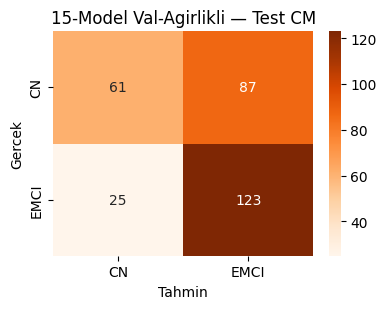

In [ ]:
# ===== EK HUCRE C: 15 MODEL — her (duzlem,fold) modeline KENDI val_acc agirligi =====
import numpy as np, os

# ANA_KLASOR = '/content/drive/MyDrive/.../DenseNet_PerPlane_Ensemble_...'

DUZLEM_KLASOR = {
    'sagital': os.path.join(ANA_KLASOR, 'Sagital'),
    'aksiyal': os.path.join(ANA_KLASOR, 'Aksiyal'),
    'koronal': os.path.join(ANA_KLASOR, 'Koronal'),
}

# 1) Her (duzlem,fold) icin VALIDATION agirligi (val_acc - 0.5)
model_agirlik = {}   # (duzlem, fold) -> agirlik
for d, klasor in DUZLEM_KLASOR.items():
    dfv = pd.read_csv(os.path.join(klasor, 'deney_sonuclari.csv'))
    for _, row in dfv.iterrows():
        model_agirlik[(d, int(row['fold']))] = max(row['val_acc'] - 0.5, 0.0)
toplam_ag = sum(model_agirlik.values())
print("15 model agirligi (validation'dan, normalize):")
for (d, fold), w in sorted(model_agirlik.items()):
    print(f"   {d.capitalize():9s} fold {fold}: {w/toplam_ag:.3f}")

# 2) Test verisi
test_config = dict(CONFIG)
test_config["kaynak_CN"]   = CONFIG["kaynak_CN_test"]
test_config["kaynak_EMCI"] = CONFIG["kaynak_EMCI_test"]
test_veriler = veri_listesi_olustur(test_config)
sid_true = {f"{x['hasta_id']}_{x['seans_id']}": x['etiket'] for x in test_veriler}

# 3) 15 modeli tek tek, kendi agirligiyla topla
toplam_olasilik = {}
for d, klasor in DUZLEM_KLASOR.items():
    test_loader = loader_olustur(test_veriler, d, CONFIG, shuffle=False)
    for fold in range(1, CONFIG['k_fold'] + 1):
        m_path = os.path.join(klasor, f'{d}_fold_{fold}.pth')
        model = SinglePlaneModel(dropout_rate=CONFIG['dropout'], hidden_dim=256).to(DEVICE)
        model.load_state_dict(torch.load(m_path, weights_only=True))
        sids, probs = tahmin_al(model, test_loader)
        w = model_agirlik[(d, fold)] / toplam_ag
        for sid, pr in zip(sids, probs):
            toplam_olasilik.setdefault(sid, np.zeros(2))
            toplam_olasilik[sid] += w * np.array(pr)
        del model; torch.cuda.empty_cache()

# 4) Karar + metrikler
y_true, y_pred = [], []
for sid in sorted(toplam_olasilik.keys()):
    y_true.append(sid_true[sid]); y_pred.append(int(np.argmax(toplam_olasilik[sid])))

acc = accuracy_score(y_true, y_pred)
p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
p_pc, r_pc, f_pc, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=[0,1], zero_division=0)
print(f"\n{'='*60}\n15-MODEL VAL-AGIRLIKLI ENSEMBLE — NIHAI TEST\n{'='*60}")
print(f"   Accuracy     : {acc:.4f}")
print(f"   Precision    : {p:.4f} | Recall: {r:.4f} | F1: {f:.4f}")
print(f"   Per-Class F1 : CN={f_pc[0]:.4f} | EMCI={f_pc[1]:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['CN','EMCI'], zero_division=0)}")

plt.figure(figsize=(4,3.2))
sns.heatmap(confusion_matrix(y_true, y_pred, labels=[0,1]), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['CN','EMCI'], yticklabels=['CN','EMCI'])
plt.title("15-Model Val-Agirlikli — Test CM")
plt.xlabel("Tahmin"); plt.ylabel("Gercek"); plt.tight_layout(); plt.show()